# **Outlier Detection and Imputation Techniques**
Manual implementation without using built-in methods


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Create a sample dataset with outliers and missing values
np.random.seed(42)
data = {
    'Age': [25, 30, 35, np.nan, 28, 90, 32, np.nan, 29, 31],
    'Salary': [50000, 60000, np.nan, 55000, 52000, 150000, 58000, 54000, np.nan, 56000],
    'Experience': [2, 5, 7, 4, np.nan, 20, 6, 4, 3, np.nan]
}
df = pd.DataFrame(data)
print("Original Dataset:")
print(df)

Original Dataset:
    Age    Salary  Experience
0  25.0   50000.0         2.0
1  30.0   60000.0         5.0
2  35.0       NaN         7.0
3   NaN   55000.0         4.0
4  28.0   52000.0         NaN
5  90.0  150000.0        20.0
6  32.0   58000.0         6.0
7   NaN   54000.0         4.0
8  29.0       NaN         3.0
9  31.0   56000.0         NaN


In [2]:
# Custom sorting function
def custom_sort(arr):
    arr = [x for x in arr if not np.isnan(x)]
    n = len(arr)
    for i in range(n):
        for j in range(0, n-i-1):
            if arr[j] > arr[j+1]:
                arr[j], arr[j+1] = arr[j+1], arr[j]
    return arr

In [3]:
# 1. Outlier Detection Methods
def detect_outliers(data, method='iqr', threshold=3):
    clean_data = [x for x in data if not np.isnan(x)]
    
    if method == 'iqr':
        sorted_data = custom_sort(clean_data)
        n = len(sorted_data)
        q1 = sorted_data[n//4]
        q3 = sorted_data[(3*n)//4]
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        outliers = [x for x in clean_data if x < lower_bound or x > upper_bound]
        
    elif method == 'zscore':
        mean = sum(clean_data) / len(clean_data)
        squared_diff = sum((x - mean) ** 2 for x in clean_data)
        std = (squared_diff / (len(clean_data) - 1)) ** 0.5
        z_scores = [(x - mean) / std for x in clean_data]
        outliers = [clean_data[i] for i in range(len(clean_data)) 
                   if abs(z_scores[i]) > threshold]
        
    elif method == 'percentile':
        sorted_data = custom_sort(clean_data)
        p1 = sorted_data[int(len(sorted_data) * 0.01)]
        p99 = sorted_data[int(len(sorted_data) * 0.99)]
        outliers = [x for x in clean_data if x < p1 or x > p99]
    
    return outliers



In [4]:
# 2. Imputation Methods
def impute_missing(data, method='mean'):
    clean_data = [x for x in data if not np.isnan(x)]
    
    if method == 'mean':
        imputation_value = sum(clean_data) / len(clean_data)
    
    elif method == 'median':
        sorted_data = custom_sort(clean_data)
        n = len(sorted_data)
        if n % 2 == 0:
            imputation_value = (sorted_data[n//2 - 1] + sorted_data[n//2]) / 2
        else:
            imputation_value = sorted_data[n//2]
    
    elif method == 'mode':
        # Simple mode implementation
        value_counts = {}
        for x in clean_data:
            value_counts[x] = value_counts.get(x, 0) + 1
        imputation_value = max(value_counts.items(), key=lambda x: x[1])[0]
    
    return [x if not np.isnan(x) else imputation_value for x in data]


In [5]:
# Apply outlier detection to each column
print("\nOutlier Detection Results:")
for column in df.columns:
    data = df[column].values
    print(f"\n{column}:")
    print("IQR Outliers:", detect_outliers(data, 'iqr'))
    print("Z-score Outliers:", detect_outliers(data, 'zscore'))
    print("Percentile Outliers:", detect_outliers(data, 'percentile'))



Outlier Detection Results:

Age:
IQR Outliers: [np.float64(90.0)]
Z-score Outliers: []
Percentile Outliers: []

Salary:
IQR Outliers: [np.float64(150000.0)]
Z-score Outliers: []
Percentile Outliers: []

Experience:
IQR Outliers: [np.float64(20.0)]
Z-score Outliers: []
Percentile Outliers: []


In [6]:
# Apply imputation to each column
print("\nImputation Results:")
df_imputed = df.copy()
for column in df.columns:
    data = df[column].values
    print(f"\n{column}:")
    print("Mean Imputation:", impute_missing(data, 'mean'))
    print("Median Imputation:", impute_missing(data, 'median'))
    print("Mode Imputation:", impute_missing(data, 'mode'))



Imputation Results:

Age:
Mean Imputation: [np.float64(25.0), np.float64(30.0), np.float64(35.0), np.float64(37.5), np.float64(28.0), np.float64(90.0), np.float64(32.0), np.float64(37.5), np.float64(29.0), np.float64(31.0)]
Median Imputation: [np.float64(25.0), np.float64(30.0), np.float64(35.0), np.float64(30.5), np.float64(28.0), np.float64(90.0), np.float64(32.0), np.float64(30.5), np.float64(29.0), np.float64(31.0)]
Mode Imputation: [np.float64(25.0), np.float64(30.0), np.float64(35.0), np.float64(25.0), np.float64(28.0), np.float64(90.0), np.float64(32.0), np.float64(25.0), np.float64(29.0), np.float64(31.0)]

Salary:
Mean Imputation: [np.float64(50000.0), np.float64(60000.0), np.float64(66875.0), np.float64(55000.0), np.float64(52000.0), np.float64(150000.0), np.float64(58000.0), np.float64(54000.0), np.float64(66875.0), np.float64(56000.0)]
Median Imputation: [np.float64(50000.0), np.float64(60000.0), np.float64(55500.0), np.float64(55000.0), np.float64(52000.0), np.float64(150

C:\Users\mujta\AppData\Local\Temp\ipykernel_11088\372431555.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df[col].dropna() for col in df.columns], labels=df.columns)


Text(0.5, 1.0, 'Original Data')

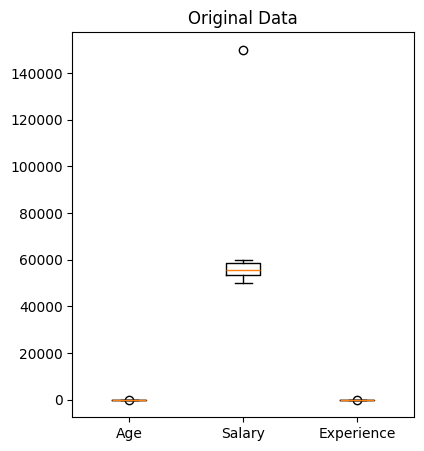

In [7]:
# Visualization
plt.figure(figsize=(15, 5))

# Original Data
plt.subplot(131)
plt.boxplot([df[col].dropna() for col in df.columns], labels=df.columns)
plt.title('Original Data')

C:\Users\mujta\AppData\Local\Temp\ipykernel_11088\203540359.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([clean_data[col].dropna() for col in clean_data.columns],


Text(0.5, 1.0, 'After Outlier Removal')

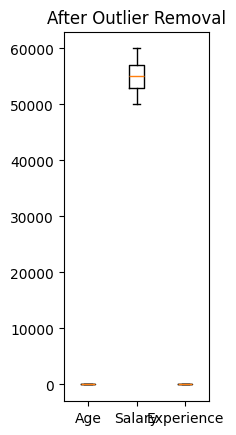

In [8]:
# After Outlier Removal (using IQR)
plt.subplot(132)
clean_data = df.copy()
for column in df.columns:
    outliers = detect_outliers(df[column].values, 'iqr')
    clean_data[column] = clean_data[column].apply(
        lambda x: np.nan if x in outliers else x)
plt.boxplot([clean_data[col].dropna() for col in clean_data.columns], 
            labels=clean_data.columns)
plt.title('After Outlier Removal')


C:\Users\mujta\AppData\Local\Temp\ipykernel_11088\1739438996.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([imputed_data[col] for col in imputed_data.columns],


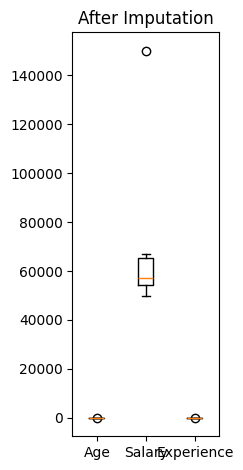

In [9]:
# After Imputation (using mean)
plt.subplot(133)
imputed_data = df.copy()
for column in df.columns:
    imputed_data[column] = impute_missing(df[column].values, 'mean')
plt.boxplot([imputed_data[col] for col in imputed_data.columns], 
            labels=imputed_data.columns)
plt.title('After Imputation')

plt.tight_layout()
plt.show()